# Half-density Lagrangian Isometries

Another natural way to define a diffeomorphism on a domain is define it through an ODE. For more information on how the transformation is done, please refer to the write-up, here we will parameterize and visualize a velocity field defined on the disk domain and see how a randomly initialized velocity field can be used for changing the basis functions.

In [1]:
%load_ext autoreload
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float64)

Run the following code to visualize the velocity field captured at random timesteps on the disk domain. Note that the velocity field is tangential to the boundary by design:

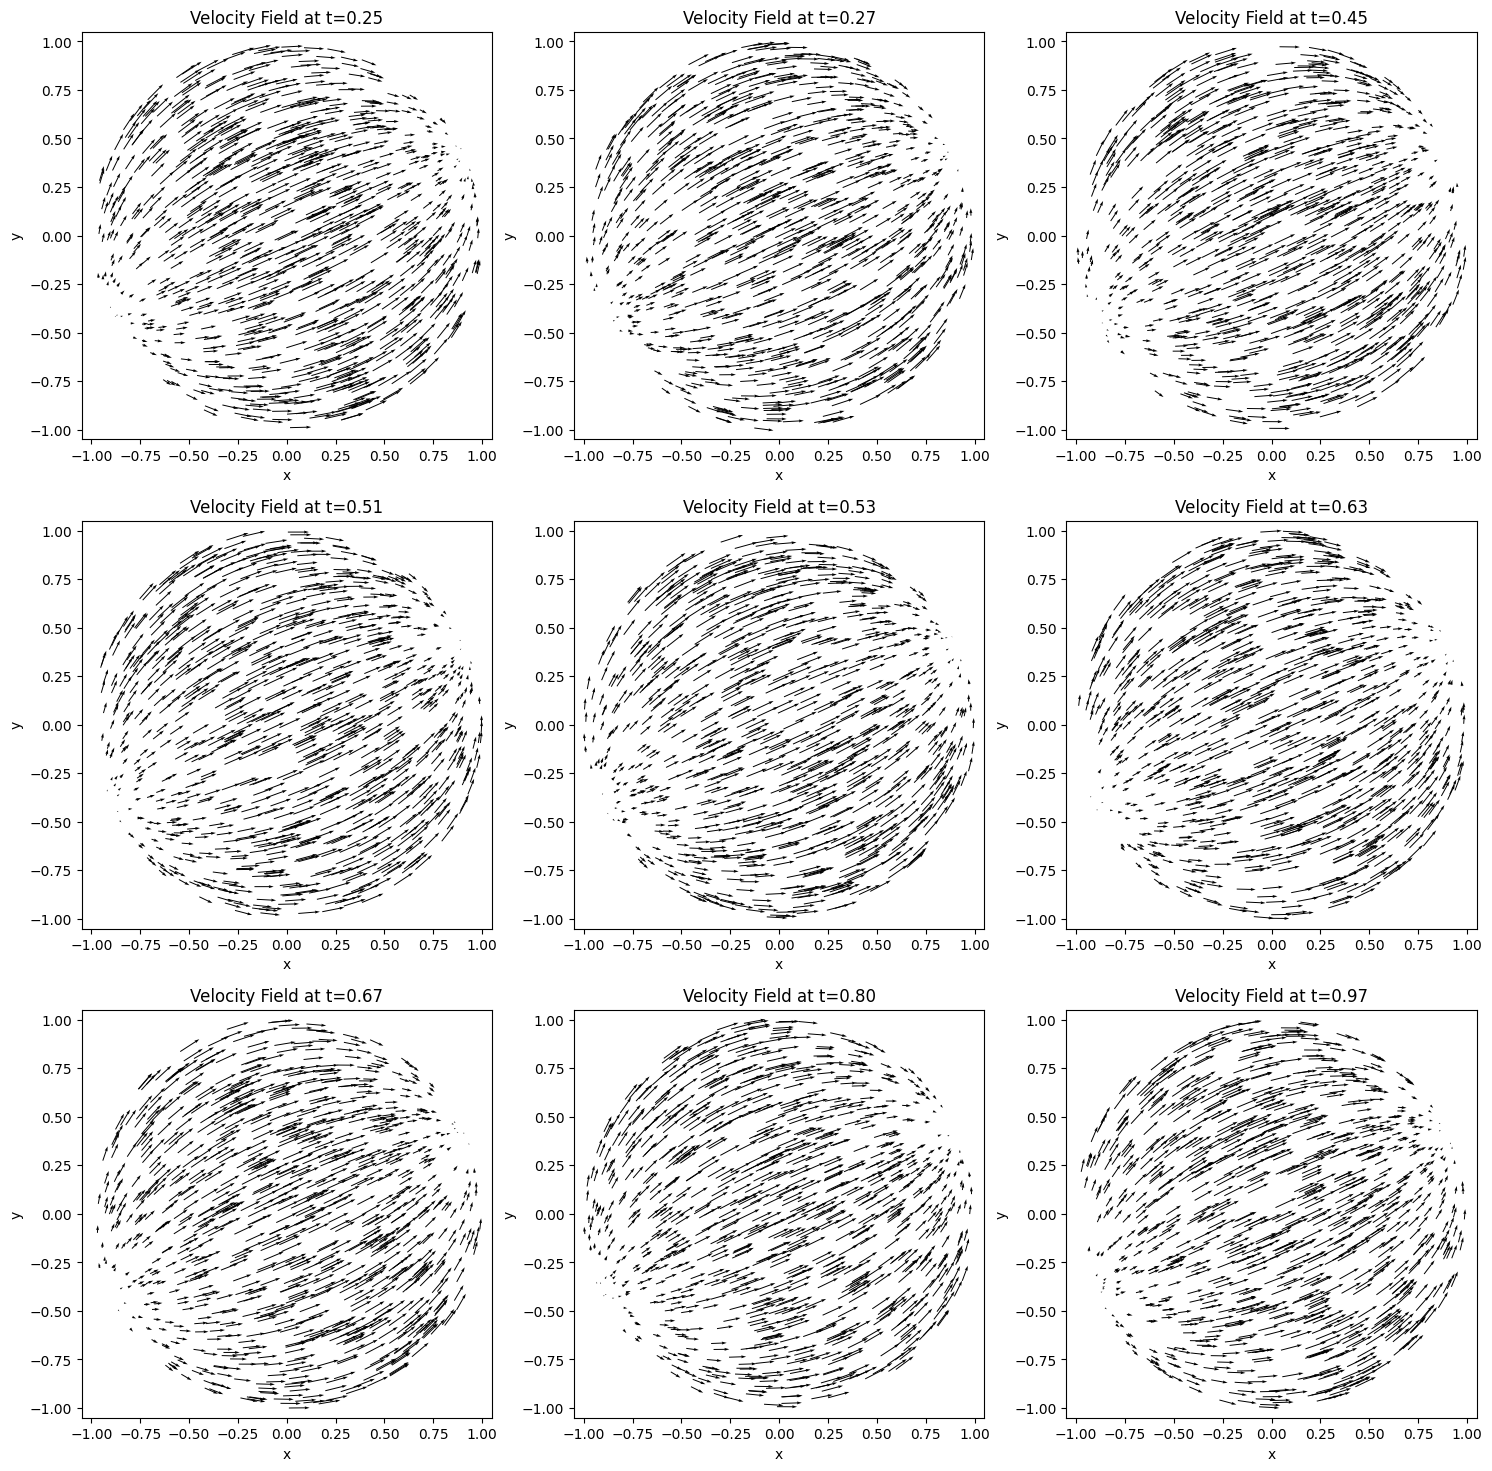

In [2]:
%autoreload 2
from infidictionary.diffeomorphisms.continuous_time import CTRadialFlow
from infidictionary.dictionaries.utils import sample_from_disk

torch.manual_seed(10)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18,18))
N = 1000
T = CTRadialFlow(
    dimensions=2,
    gamma=1.,
    use_adjoint=True,
    method='dopri5',
    rtol=1e-6,
    atol=1e-6,
    start_time=0.,
    end_time=10.0,
).to(device)
viz_magnitude = 10.0

xy = sample_from_disk(N * 9).to(device)

# sample 9 random times in [0,1] and sample
# the velocity field at those times at random points
# on the domain
t = torch.rand(9).to(device)
t, _ = torch.sort(t)
t = torch.repeat_interleave(t, N)
v = viz_magnitude * T.velocity_field(t, xy)


for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        idx = row * 3 + col
        ax.quiver(xy[idx * N:(idx + 1) * N,0].detach().cpu(), xy[idx * N:(idx + 1) * N,1].detach().cpu(),
                  v[idx * N:(idx + 1) * N,0].detach().cpu(), v[idx * N:(idx + 1) * N,1].detach().cpu(),
                  angles='xy', scale_units='xy', scale=10.0, alpha=1)
        ax.set_title(f'Velocity Field at t={t[idx * N].item():.2f}')
        ax.set_xlim(-1.05,1.05)
        ax.set_ylim(-1.05,1.05)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
plt.show()


Inverse consistency check passed with max L-inf norm: 0.09065760210822105
Determinant consistency check passed with max abs error: 0.09789489818957842


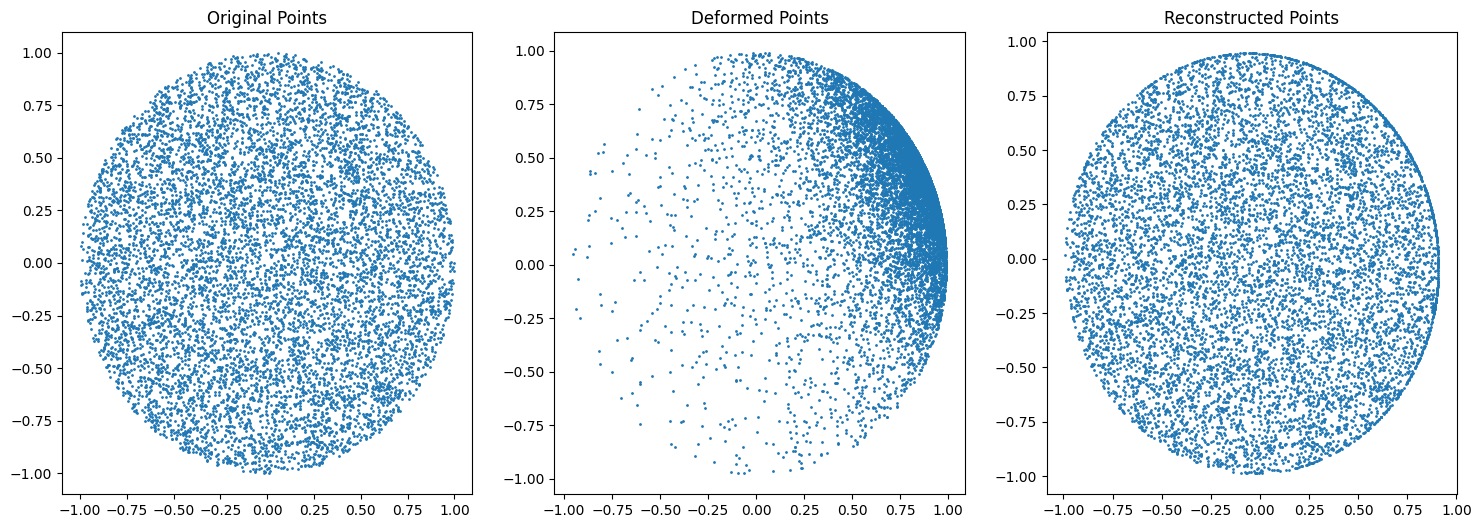

In [3]:
import matplotlib.pyplot as plt

# check the forward and inverse
# Forward map and determinant of Jacobian
xy_deformed, detJ = T.forward(xy)
xy_back, detJ_inv = T.inverse(xy_deformed)

#  check y max and min is in the box
# assert (xy_deformed >= 0).all() and (xy_deformed <= 1).all(), "Forward map output is out of bounds with values: min {}, max {}".format(xy_deformed.min().item(), xy_deformed.max().item())
l_inf_norm = (xy - xy_back).abs().max().item()
assert l_inf_norm < 1e-1, f"Inverse consistency check failed! {l_inf_norm}"
print(f"Inverse consistency check passed with max L-inf norm: {l_inf_norm}")
detJ_consistency = (torch.exp(detJ + detJ_inv) - 1).abs().max().item()
assert detJ_consistency < 1e-1, f"Determinant consistency check failed! {detJ_consistency}"
print(f"Determinant consistency check passed with max abs error: {detJ_consistency}")

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18,6))
# scatterplot xy
axes[0].scatter(xy[:,0].detach().cpu(), xy[:,1].detach().cpu(), s=1)
axes[0].set_title("Original Points")
axes[1].scatter(xy_deformed[:,0].detach().cpu(), xy_deformed[:,1].detach().cpu(), s=1)
axes[1].set_title("Deformed Points")
axes[2].scatter(xy_back[:,0].detach().cpu(), xy_back[:,1].detach().cpu(), s=1)
axes[2].set_title("Reconstructed Points")
plt.show()

Next, try running the ODE to deform an original tent basis:

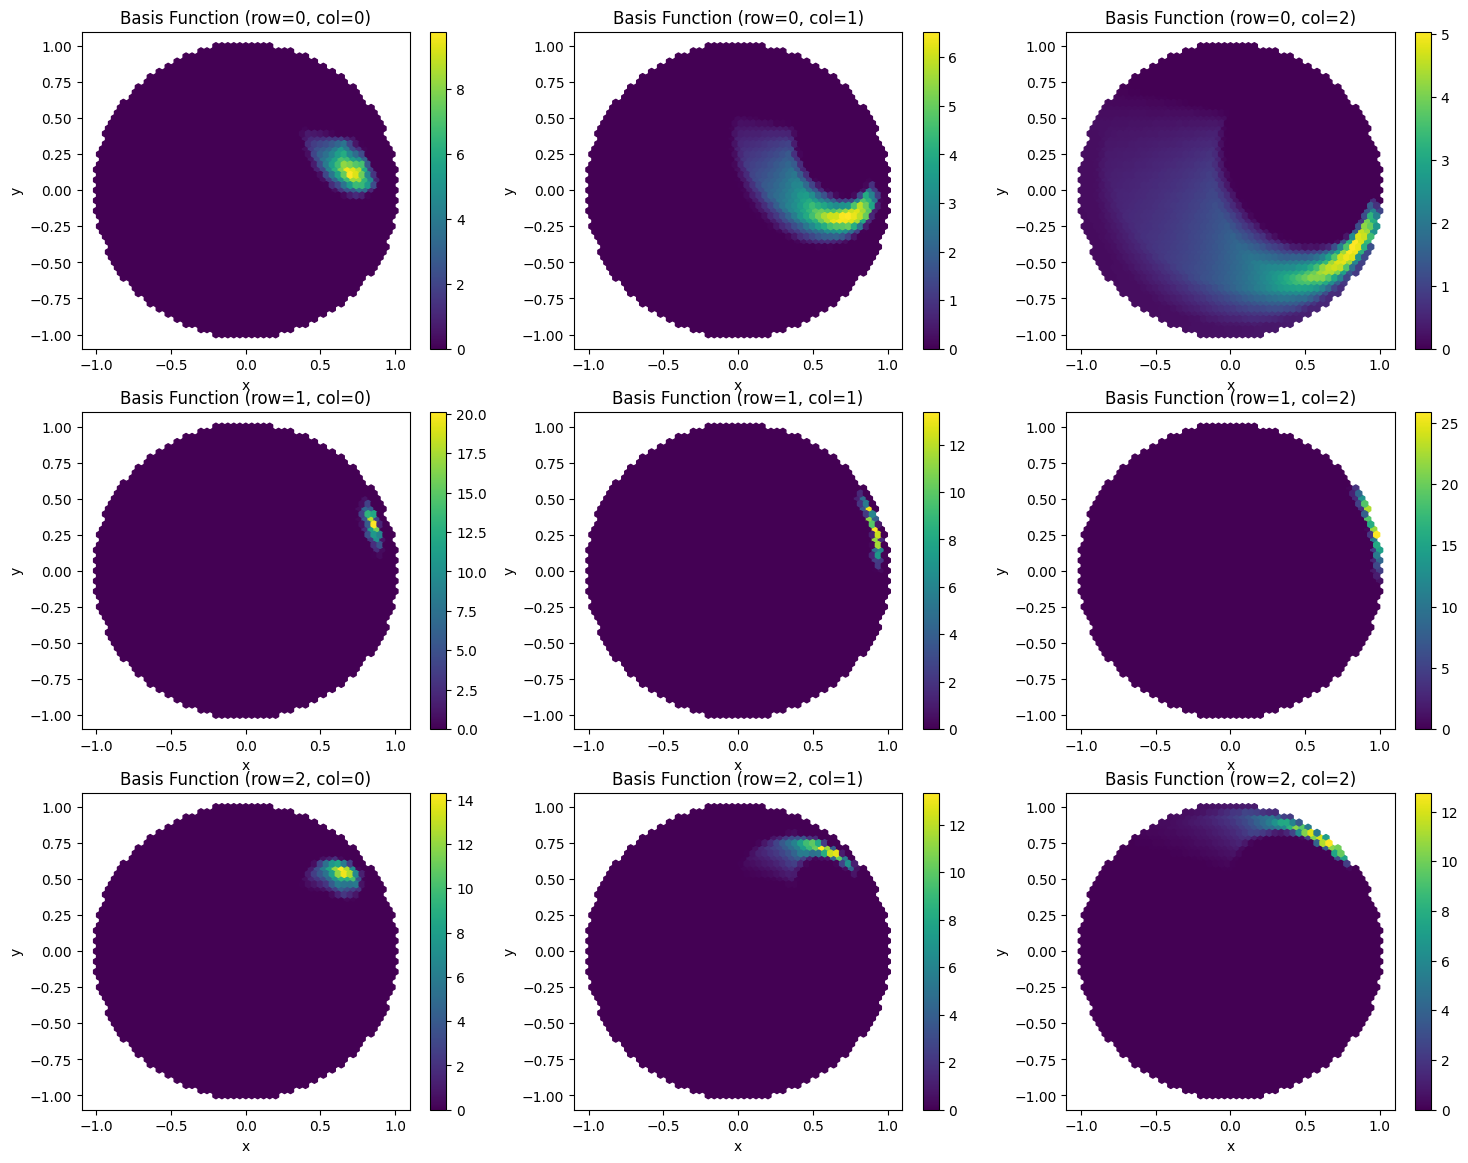

In [ ]:
%autoreload 2
from infidictionary.dictionaries import RadialTentDictionary
from infidictionary.diffeomorphisms import HalfDensityIsometry
from infidictionary.diffeomorphisms import IdentityFlow

neural_isometry = HalfDensityIsometry(
    initial_diffeomorphism=IdentityFlow(),
    diffeomorphism=T,
)
tent_basis = RadialTentDictionary(
    total_rows=3,
    total_cols=3,
)
indices = [
    [0, 1, 2],
    [3, 4, 5],
    [6, 7, 8],
]
indices_tensorized = torch.tensor(indices).to(device).flatten()
# seed everything for reproducibility
torch.manual_seed(0)
N = 50000
end_time = 5.5
all_deformed_vals = []
all_vals = []
xy = tent_basis.sample_from_domain(N).to(device)
all_vals = tent_basis.get_atom(xy, indices_tensorized)
all_vals_transformed = neural_isometry.transform(
    initial_dictionary=tent_basis,
    atom_indices=indices_tensorized,
    coords=xy,
    device=device,
    mode='pushforward',
)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18,14))
for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        idx = indices[row][col]
        # approximate integral by monte carlo
        ax.hexbin(
            xy[:,0].detach().cpu(), 
            xy[:,1].detach().cpu(), 
            C=all_vals_transformed[row * 3 + col].detach().cpu(), 
            gridsize=50, 
            cmap='viridis',
        ) 
        plt.colorbar(mappable=ax.collections[0], ax=ax)
        ax.set_title(f'Basis Function (row={row}, col={col})')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
plt.show()

Now visualize the inner products of the tent basis before and after the transformation:

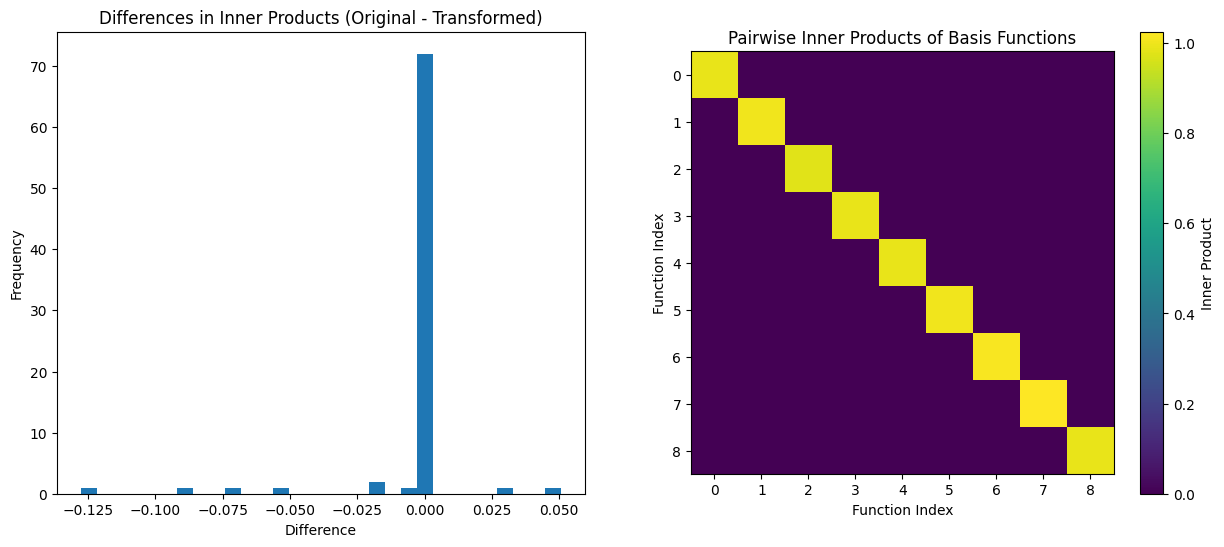

In [5]:
# compute pairwise inner products
inner_products = np.zeros((9, 9))
inner_products_transformed = np.zeros((9, 9))
fig, axes = plt.subplots(figsize=(15, 6), nrows=1, ncols=2)
inner_products_transformed = (all_vals_transformed @ all_vals_transformed.T / N).detach().cpu()
inner_products = (all_vals @ all_vals.T / N).detach().cpu()
# heatmap of inner products
m = axes[1].imshow(inner_products)
# axes[1].
fig.colorbar(m, ax=axes[1], label='Inner Product')
axes[1].set_title('Pairwise Inner Products of Basis Functions')
axes[1].set_xlabel('Function Index')
axes[1].set_ylabel('Function Index')

diffs = inner_products - inner_products_transformed
axes[0].hist(diffs.flatten(), bins=30)
axes[0].set_title('Differences in Inner Products (Original - Transformed)')
axes[0].set_xlabel('Difference')
axes[0].set_ylabel('Frequency')
plt.show()
